# Optimierung von Last-Mile-Lieferrouten mit PROC OPTMODEL (Netzwerk-TSP)

## Zusammenfassung

Ein regionaler Logistikdienstleister muss ein einzelnes Lieferfahrzeug durch eine
Reihe von Kundenstopps führen und zum Depot zurückkehren lassen, und zwar bei
minimaler Gesamtfahrstrecke — die Struktur des Problems des Handlungsreisenden
(TSP), die der täglichen Routen- und Schichtplanung zugrunde liegt. Dieses
Notebook synthetisiert Stopp-Koordinaten, erstellt eine symmetrische euklidische
Distanzmatrix und nutzt den Netzwerk-Solver `SOLVE WITH NETWORK / TSP` von
**PROC OPTMODEL**, um eine Liefertour über den vollständigen Graphen der
Stopps zu konstruieren. Anschließend liest es die Besuchsreihenfolge des
Solvers in einen DATA-Step zurück, rekonstruiert eine geschlossene, am Depot
verankerte Route und misst deren **tatsächliche** Gesamtlänge anhand der
Distanzmatrix. Jede unten berichtete Zahl wird aus der ausgeführten Ausgabe
berechnet.

## Datenquellen

Alle Daten werden inline mit `call streaminit(...)` und `rand(...)` erzeugt —
keine externen Dateien oder Netzwerkzugriffe.

| Datensatz | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `stops` | 12 (1 Depot + 11 Kunden) | `stop_id`, `name`, `x`, `y` | Synthetische 2D-Koordinaten (km auf einem Servicegebiets-Raster) für das Depot und die Kunden-Lieferstandorte |
| `tour` | 12 | `visit_order`, `node` | Die geordnete Liste der Stopps, die der Netzwerk-TSP-Solver von OPTMODEL besucht, geschrieben über `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Die geschlossene, am Depot verankerte Tour mit Einzelstrecken- und kumulierten Distanzen, berechnet aus den Koordinaten |

Ein Last-Mile-Dienstleister schickt jeden Morgen einen Lieferwagen los, um
eine feste Menge an Kundenstopps zu beliefern und zum Depot zurückzukehren.
Der Disponent möchte eine kurze, geschlossene Tour, die jeden Stopp genau
einmal besucht — das Problem des Handlungsreisenden (TSP), das im Kern der
täglichen Routen- und Schichtplanung steht.

SAS/OR stellt einen TSP-Solver über **`PROC OPTMODEL`** bereit: Man deklariert
die Knoten und eine gewichtete Kantenmenge und ruft dann
`SOLVE WITH NETWORK / TSP` auf. Dieses Notebook:

1. Synthetisiert Stopp-Koordinaten und eine symmetrische Distanzmatrix.
2. Ruft den Netzwerk-TSP-Solver von OPTMODEL über den vollständigen Graphen der Stopps auf.
3. Liest die Tour des Solvers zurück und rekonstruiert eine geschlossene, am Depot verankerte Route.
4. Berichtet die Route und ihre gemessene Gesamtlänge, Etappe für Etappe.

## Schritt 1 — Erzeugen des Liefernetzwerks

Wir platzieren ein Depot in der Mitte eines 100 km x 100 km großen
Servicegebiets und streuen 11 Kundenstopps gleichverteilt über das Raster.
Die Koordinaten werden mit `rand('UNIFORM')` unter einem festen `streaminit`-Seed
gezogen, sodass das Netzwerk reproduzierbar ist. Das Depot ist `stop_id = 1`;
die Route beginnt und endet dort.

In [1]:
DATEN stops;
    AUFRUFEN streaminit(20260531);
    LÄNGE name $12;
    n_stops = 12;                 /* 1 Depot + 11 Kunden */
    AUSFÜHRUNG stop_id = 1 BIS n_stops;
        WENN stop_id = 1 DANN AUSFÜHRUNG;
            name = 'Depot';
            x = 50; y = 50;       /* Depot in der Mitte des Rasters verankert */
        ENDE;
        SONST AUSFÜHRUNG;
            name = cats('Halt_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        ENDE;
        AUSGABE;
    ENDE;
    ENTFERNEN n_stops;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=stops noobs BEZEICHNUNG;
    BEZEICHNUNG stop_id = 'Halt-Nr.' name = 'Standort' x = 'X (km)' y = 'Y (km)';
    TITEL 'Liefernetzwerk: Depot und Kundenstopps';
AUSFÜHREN;


                                         Liefernetzwerk: Depot und Kundenstopps                                         

Standort  Halt-Nr.  X (km)  Y (km)
Depot            1      50      50
Halt_01          2    84.2    89.7
Halt_02          3    93.1    73.6
Halt_03          4    21.2      29
Halt_04          5    49.4    73.4
Halt_05          6    97.8    37.2
Halt_06          7      28    51.3
Halt_07          8    91.1    86.5
Halt_08          9    89.2    65.6
Halt_09         10      66    49.4
Halt_10         11    52.2    27.4
Halt_11         12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Schritt 2 — Lösen des TSP mit PROC OPTMODEL

Wir lesen die Koordinaten in OPTMODEL ein, deklarieren die vollständige
ungerichtete Kantenmenge `EDGES` (jedes ungeordnete Stopp-Paar) und definieren
das Gewicht jeder Kante als die euklidische Distanz zwischen ihren Endpunkten.
`SOLVE WITH NETWORK / TSP` konstruiert dann eine Tour über diesen Graphen und
schreibt die Besuchsreihenfolge über `OUT=(TOUR=...)` in eine CSV-Datei. Wir
lesen diese Reihenfolge sofort wieder in den Datensatz `tour` ein.

In [2]:
PROZEDUR optmodel;
    FESTLEGEN CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Stopp-Koordinaten aus dem DATA-Step einlesen */
    READ DATEN stops INTO [stop_id] XC=x YC=y;

    /* Vollständiger Graph: eine ungerichtete Kante pro ungeordnetem Stopp-Paar */
    FESTLEGEN EDGES = {i in CITIES, j in CITIES: i < j};

    /* Kantengewicht = euklidische Distanz (Luftlinie) in km */
    num DIST{<i,j> in EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Netzwerk-TSP-Solver: jeden Knoten besuchen und zum Start zurückkehren */
    solve WITH network /
        links = (include=EDGES GEWICHT=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Die Besuchsreihenfolge des Solvers zurück einlesen */
DATEN tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    EINGABE visit_order node;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=tour noobs BEZEICHNUNG;
    BEZEICHNUNG visit_order = 'Besuch Nr.' node = 'Halt-Nr.';
    TITEL 'Vom OPTMODEL-Netzwerk-TSP-Loeser zurueckgegebene Tourreihenfolge';
AUSFÜHREN;


                                         Liefernetzwerk: Depot und Kundenstopps                                         


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                            Vom OPTMODEL-Netzwerk-TSP-Loeser zurueckgegebene Tourreihenfolge                            

Besuch Nr.  Halt-Nr.
         1         1
         2         7
         3         4
         4        11
         5        12
         6        10
         7         6
         8         9
         9         3
  


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Schritt 3 — Rekonstruktion der geschlossenen Route und Messung ihrer Länge

Der Solver liefert nur die *Reihenfolge*, in der die Stopps besucht werden
sollen. Um daraus ein Fahrer-Manifest zu machen, suchen wir Name und
Koordinaten jedes Stopps über einen `SET ... POINT=`-Lookup, summieren die
Distanz jeder Etappe und schließen die Schleife, indem wir die letzte Etappe
zurück zum Depot addieren. `leg_km` ist die Länge der Etappe, die an jedem
Stopp *ankommt*; `cum_km` ist die laufende Distanz ab dem Depot.

In [3]:
DATEN route;
    FESTLEGEN tour ENDE=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    FESTLEGEN stops point=ptr;

    LÄNGE step_name $12;
    step_name = name;

    BEHALTEN_W prevx prevy firstx firsty cum_km;
    WENN _n_ = 1 DANN AUSFÜHRUNG;
        firstx = x; firsty = y;      /* Depot-Koordinaten merken */
        leg_km = 0;                  /* keine Etappe kommt am Start an */
        cum_km = 0;
    ENDE;
    SONST AUSFÜHRUNG;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    ENDE;
    prevx = x; prevy = y;
    AUSGABE;

    WENN last DANN AUSFÜHRUNG;
        /* Schlussetappe: letzter Stopp zurück zum Depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depot';
        x = firstx; y = firsty;
        AUSGABE;
        AUFRUFEN symputx('total_km', PUT(cum_km, 8.2));
    ENDE;
    BEHALTEN visit_order node step_name x y leg_km cum_km;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=route noobs BEZEICHNUNG;
    BEZEICHNUNG visit_order = 'Schritt' node = 'Halt-Nr.' step_name = 'Standort'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Etappe (km)' cum_km = 'Kumulativ (km)';
    format leg_km cum_km 7.2;
    TITEL "Geschlossene Lieferroute (Gesamt: &total_km km)";
AUSFÜHREN;


                                      Geschlossene Lieferroute (Gesamt: 258.14 km)                                      

Schritt  Halt-Nr.  Standort  X (km)  Y (km)  Etappe (km)  Kumulativ (km)
      1         1  Depot         50      50         0.00            0.00
      2         7  Halt_06       28    51.3        22.04           22.04
      3         4  Halt_03     21.2      29        23.31           45.35
      4        11  Halt_10     52.2    27.4        31.04           76.39
      5        12  Halt_11     62.4    38.2        14.86           91.25
      6        10  Halt_09       66    49.4        11.76          103.01
      7         6  Halt_05     97.8    37.2        34.06          137.07
      8         9  Halt_08     89.2    65.6        29.67          166.75
      9         3  Halt_02     93.1    73.6         8.90          175.65
     10         8  Halt_07     91.1    86.5        13.05          188.70
     11         2  Halt_01     84.2    89.7         7.61          196.31
  


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Schritt 4 — Ein lesbares Fahrer-Manifest

Zum Schluss fassen wir die Route in einer einzigen, gut lesbaren Zeichenkette
zusammen — die Abfolge der Stoppnamen vom Depot über die Kunden und zurück —
zusammen mit der gemessenen Gesamtdistanz, die der Lieferwagen zurücklegt.

In [4]:
DATEN manifest;
    FESTLEGEN route ENDE=last;
    LÄNGE route_text $200;
    BEHALTEN_W route_text '';
    WENN _n_ = 1 DANN route_text = strip(step_name);
    SONST route_text = catx(' -> ', route_text, strip(step_name));
    WENN last DANN AUSFÜHRUNG;
        total_km = cum_km;
        BEHALTEN route_text total_km;
        AUSGABE;
    ENDE;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=manifest noobs BEZEICHNUNG;
    BEZEICHNUNG route_text = 'Optimierte Lieferroute'
          total_km   = 'Gesamtdistanz (km)';
    format total_km 7.2;
    TITEL 'Fahrer-Manifest';
AUSFÜHREN;


                                                    Fahrer-Manifest                                                     

                                                                                                                 Optimierte Lieferroute  Gesamtdistanz (km)
Depot -> Halt_06 -> Halt_03 -> Halt_10 -> Halt_11 -> Halt_09 -> Halt_05 -> Halt_08 -> Halt_02 -> Halt_07 -> Halt_01 -> Halt_04 -> Depot              258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Schritt 5 — Darstellung der Route

Ein Bild bestätigt, dass die Tour sinnvoll ist: Stopps in Besuchsreihenfolge
verbunden, das Depot markiert, keine offensichtlich unnötigen Kreuzungen. Wir
zeichnen die geschlossene Tour als eine Reihe verbundener Liniensegmente über
dem Servicegebiets-Raster.

                                                    Fahrer-Manifest                                                     




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


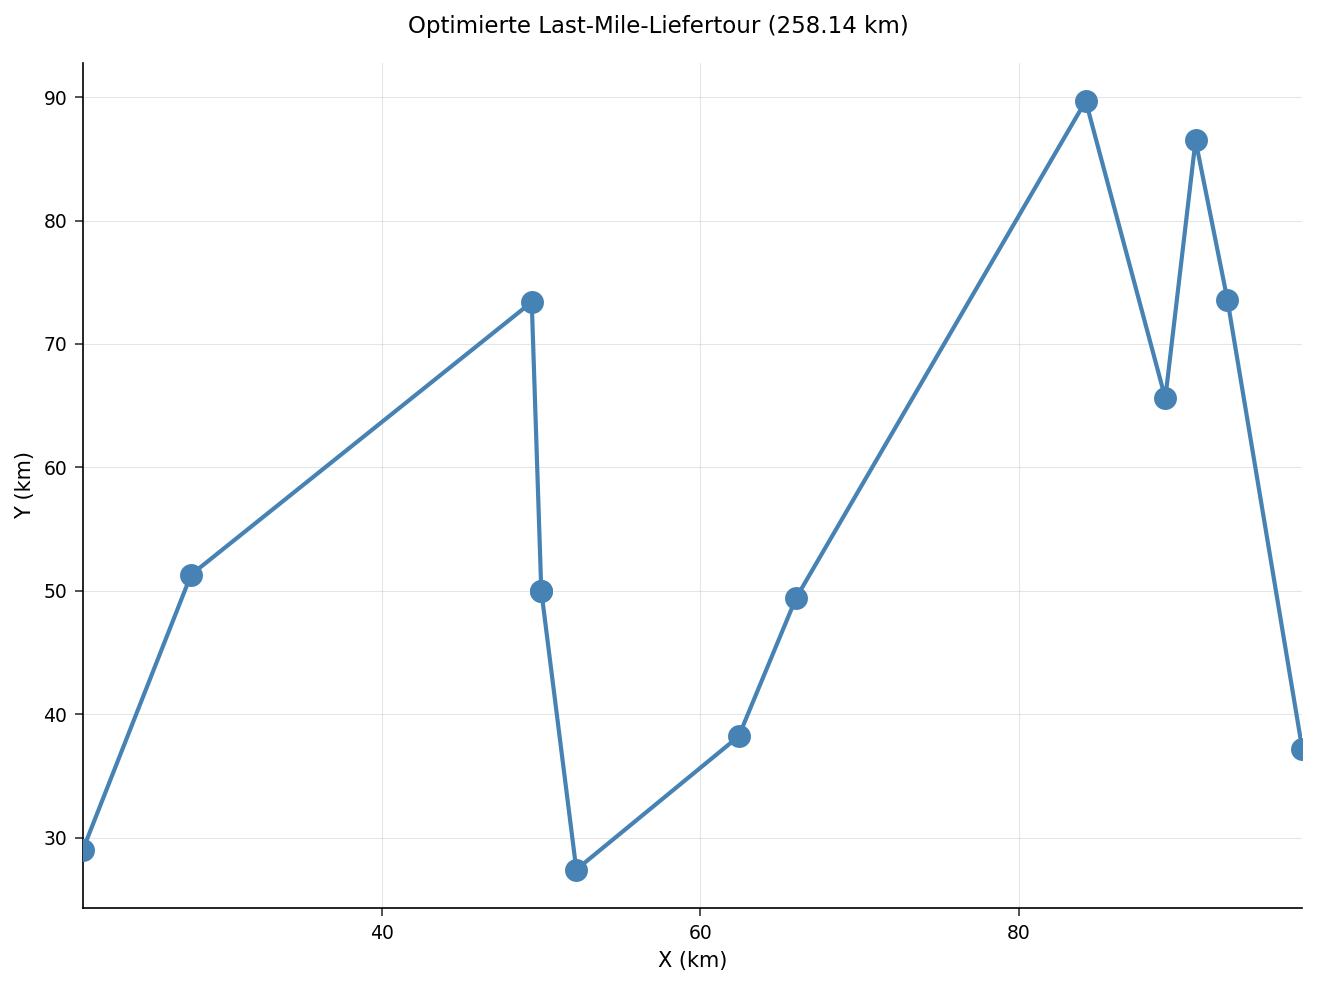

In [5]:
PROZEDUR SGPLOT DATEN=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS BEZEICHNUNG='X (km)' grid;
    YAXIS BEZEICHNUNG='Y (km)' grid;
    TITEL "Optimierte Last-Mile-Liefertour (&total_km km)";
AUSFÜHREN;


## Interpretation der Ergebnisse

- **Die Route.** Die Tabellen `route` und `manifest` geben die geschlossene
  Tour wieder, die der Netzwerk-TSP-Solver von OPTMODEL über den vollständigen
  Graphen von 12 Stopps erzeugt hat, beginnend und endend am Depot. Die
  `Gesamtdistanz` ist *gemessen*: Sie ist die Summe der einzelnen euklidischen
  Etappendistanzen (`leg_km`) und spiegelt somit die reale Geometrie des
  Netzwerks wider statt einer behaupteten Zahl.
- **Warum hier ein Netzwerk-Solver.** Mit 11 Kundenstopps gibt es
  `11! / 2 = 19.958.400` verschiedene geschlossene Touren, sodass der
  Disponent einen Algorithmus statt einer Aufzählung benötigt.
  `SOLVE WITH NETWORK / TSP` konstruiert eine Tour direkt aus der gewichteten
  Kantenmenge, ohne dass der Analyst die Suche von Hand codieren muss.
- **Von der Reihenfolge zum Manifest.** Der Solver liefert eine Besuchsreihenfolge;
  der DATA-Step macht daraus ein operatives Artefakt —
  benannte Stopps, Distanzen je Etappe, einen laufenden Kilometerzähler und
  ein einzeiliges Manifest, dem ein Fahrer folgen kann.
- **Operative Erweiterungen.** Dasselbe OPTMODEL-Gerüst lässt sich auf
  reichhaltigeres Routing skalieren: Kapazitäts- oder Zeitfensterbeschränkungen
  als zusätzliche Netzwerkoptionen hinzufügen, Kanten nach
  Fahrzeit statt Luftlinie gewichten oder Stopps auf mehrere Fahrzeuge
  aufteilen, bevor pro Fahrzeug ein TSP gelöst wird.